Clustering de datos. Para el dataset clustering.csv realizar los siguientes análisis:

Fragmento aleatorio de muestras


,A,B
1199,551464,437752
3384,110917,233442
903,249734,767527
1698,441386,593318
887,309129,744956
1339,796846,214589
40,838906,655174



Rango de valores de cada columna


,A,B
min,55608.0,25631.0
max,983609.0,984555.0



Categorías con valores faltantes
 Series([], )

Filas duplicadas: 0


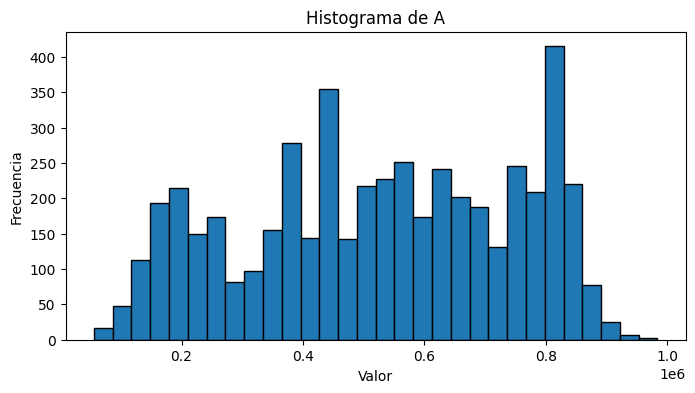

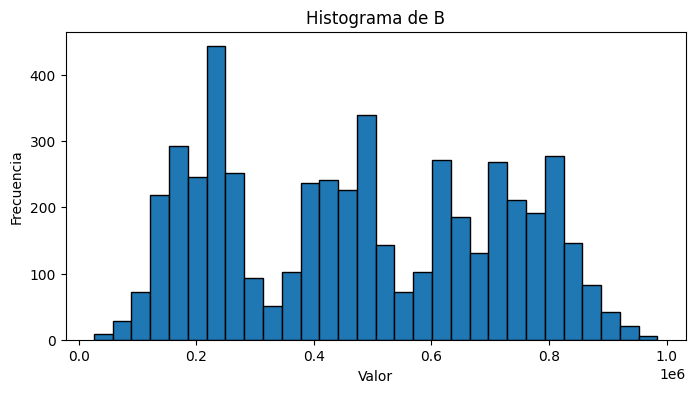

In [2]:
from src.visualization import explore_data, plot_histograms
from src.clustering_models import kmeans
import pandas as pd
data = pd.read_csv('data\clustering.csv', index_col=0)

explore_data(data)
plot_histograms(data)

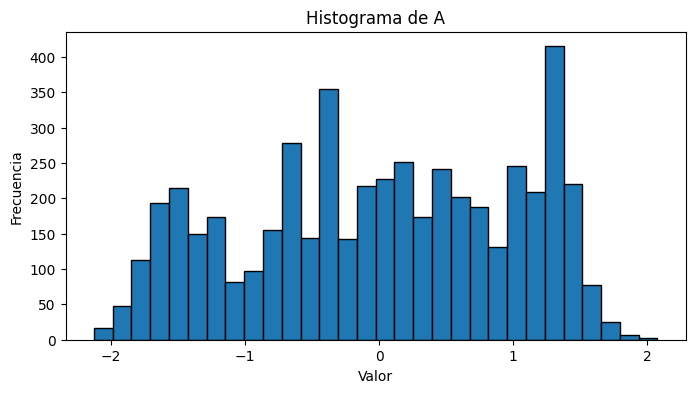

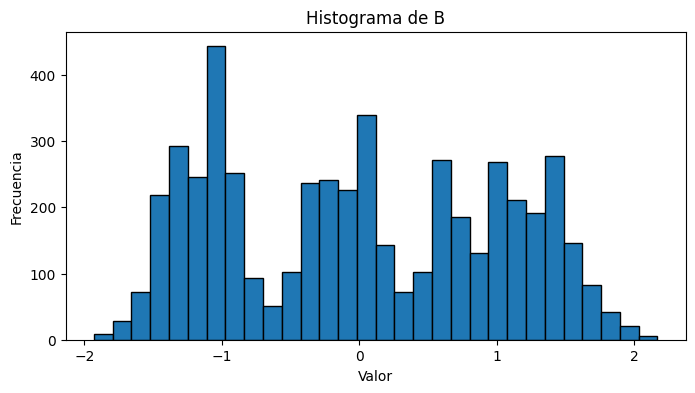

In [3]:
from src.preprocessing import standard_fit, standard_transform
media, std = standard_fit(data['A'])
data['A'] = standard_transform(data['A'], media, std)
media, std = standard_fit(data['B'])
data['B'] = standard_transform(data['B'], media, std)
plot_histograms(data)

a) Implementar el algoritmo K-means y determinar la cantidad de clusters con el método de
“ganancias decrecientes” (graficar L vs. K, y elegir un valor K donde al aumentar K deje
de reducir significativamente L, donde L es la suma de las distancias). Graficar el conjunto
de datos xi mostrando a qué cluster pertenece cada dato (usando colores/marcadores
distintos para cada cluster) y también mostrar el centroide de cada cluster.

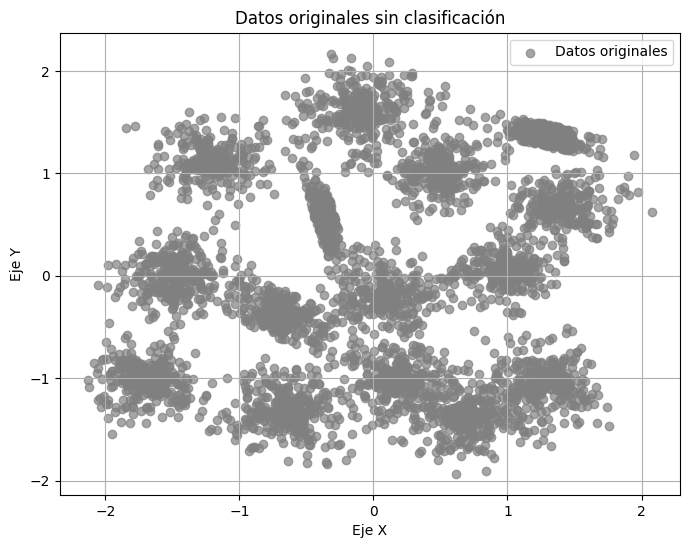

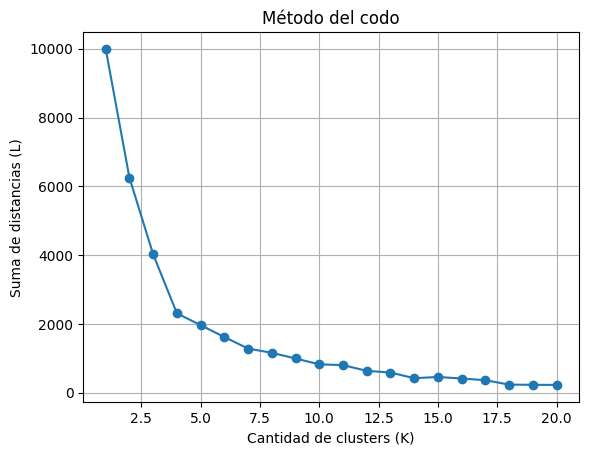

,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6,Cluster 7,Cluster 8,Cluster 9,Cluster 10,Cluster 11,Cluster 12,Cluster 13,Cluster 14,Cluster 15,Cluster 16,Cluster 17,Cluster 18,Cluster 19,Cluster 20
K,1.0,2.00,3.00,4.00,5.00,6.00,7.00,8.00,9.00,10.00,11.0,12.00,13.00,14.00,15.00,16.0,17.00,18.00,19.00,20.00
L,9996.0,6252.65,4023.56,2310.21,1964.69,1620.62,1284.46,1161.42,996.82,825.57,804.2,636.98,588.89,422.53,459.57,413.7,365.32,236.73,231.55,228.04


In [4]:
from src.visualization import plot_data, plot_elbow_method
plot_data(data)
plot_elbow_method(data, 10)



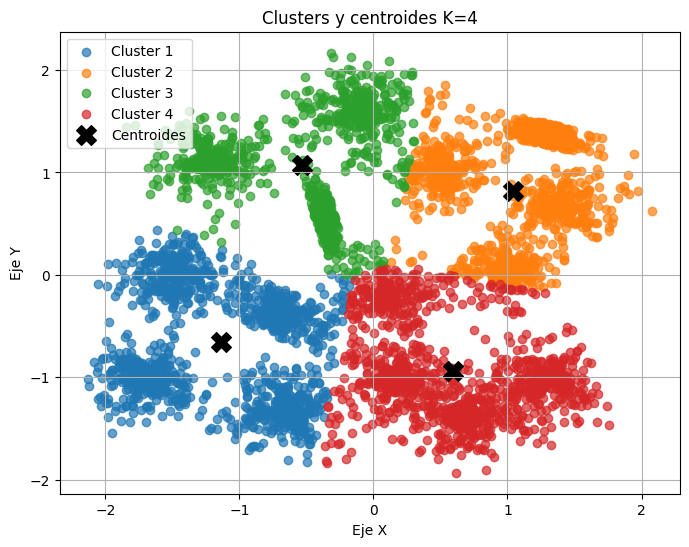

In [5]:
from src.visualization import plot_clusters
data_array = data.values  # Convertir DataFrame a array de NumPy

# Crear modelo con K=4
model_kmeans = kmeans(data_array, n_clusters=4)
plot_clusters(data_array, model_kmeans)


Implementar el algoritmo Gaussian Mixture Model (GMM) y realizar la misma tarea que
en el inciso anterior. Recuerde que puede inicializar la optimización de GMM con una
corrida de K-means.

In [6]:
from src.clustering_models import GMM
model_gmm = GMM(
    data_array,
    n_components=4,
    init_means=model_kmeans.centroids,
    init_labels=model_kmeans.labels
)